# Hierarchical Clustering - UPGMA

---
## Learning Objectives

1. Implement a distance-based phylogeny neighbor joining algorithm
1. Understanding of hierarchical clustering
1. Manipulation of arrays and lists in Python


---
## Imports
You will need to install a two new packages to properly render your phylogenetic trees. Using your preferred package manager, install both [`biopython`](https://biopython.org/) and `matplotlib` into your virtual environments.

For example:
```bash
$ micromamba create -n module06 -c bioconda -c conda-forge python numpy matplotlib biopython
```

In [1]:
from typing import List, Tuple
import numpy as np
from matplotlib import pyplot as plt
from io import StringIO
from Bio import Phylo
from distance_matrix import read_fasta, build_distance_matrix

---
## Background

Today we will implement a distance-based phylogenetic tree construction method using the Neighbor-Joining (NJ) algorithm and Smith-Waterman local alignment scores. Unlike UPGMA (Unweighted Pair Group Method using Arithmetic averages), NJ produces unrooted trees and does not assume a constant evolutionary rate across lineages, making it more biologically realistic for analyzing sequence relationships.

We will use HIV-1 reverse transcriptase sequences to construct our phylogenetic tree. The Smith-Waterman algorithm will be used to generate pairwise local alignment scores, which will then be converted into distances for tree construction. This approach is particularly suitable for HIV sequence analysis as it:
1. Handles sequence variations effectively through local alignment
2. Accounts for potential rate heterogeneity across different viral strains
3. Does not assume a molecular clock

The ultimate output will be an unrooted phylogenetic tree representing the evolutionary relationships between the HIV-1 sequences, visualized using the ete3 library. This method provides insights into viral diversity and evolutionary patterns while avoiding the assumptions of simpler hierarchical clustering approaches.

The key innovations of this implementation are:
- Use of Smith-Waterman for sensitive local alignment scoring
- Implementation of Neighbor-Joining for unrooted tree construction
- More biologically realistic evolutionary model

## Neighbor-Joining Algorithm

**Input**: Distance matrix $D$ for $n$ sequences

**Initialization**:
- Let $n$ be the number of sequences
- Assign each sequence $i$ to its own leaf node
- Initialize tree $T$ with leaf nodes

**Iteration**:
While $n > 2$:
1. Calculate Q-matrix where:
   $Q(i,j) = (n-2)d(i,j) - \sum_{k=1}^n d(i,k) - \sum_{k=1}^n d(j,k)$

2. Find pair $(i,j)$ with minimum $Q(i,j)$

3. Calculate branch lengths:
   $d_i = \frac{d(i,j) + (r_i - r_j)/(n-2)}{2}$
   $d_j = d(i,j) - d_i$
   where $r_i = \sum_{k=1}^n d(i,k)$

4. Create new node $k$
   - Add branches from $k$ to $i$ and $j$ with lengths $d_i$ and $d_j$

5. Update distances to remaining nodes $x$:
   $d(k,x) = \frac{d(i,x) + d(j,x) - d(i,j)}{2}$

6. Remove nodes $i$ and $j$
7. Add node $k$ to active nodes
8. $n = n - 1$

**Termination**:
When $n = 2$ with remaining nodes $i$ and $j$:
- Add final branch between $i$ and $j$ with length $d(i,j)$
- Return unrooted tree $T$

---
## Distance metrics for comparing sequences

### Smith-Waterman
This was previously implemented. Feel free to import if you know how...or Copy & Paste.



In [2]:
def neighbor_joining(distance_matrix: np.ndarray, labels: List[str]) -> str:
    """Implements Neighbor-Joining algorithm for phylogenetic tree construction.

        Args:
            distance_matrix (np.ndarray): Distance matrix from Smith-Waterman scores
            labels (List[str]): Sequence identifiers

        Returns:
            str: Newick format tree string
    """
    # Initialization
    D = distance_matrix.astype(float).copy() # Copy of distance matrix

    labels = list(labels) # Labels containing sequenceIDs

    n = len(labels) # number of active nodes

    # Dictionary mapping each node to its newick string
    # key = node name ( sequenceID or internal_node_x)
    # value = newick string for the key node
    newick_nodes = {}

    # Loop to go through every label in the list and set each one
    # as its own newick string
    for label in labels:
        newick_nodes[label] = label

    # counter increments each iteration so internal node name is always unique
    counter = 0

    # Start Iteration
    while n > 2:
        # Compute row sum for every row in the distance matrix
        row_sums = np.sum(D, axis=1)

        # Fill Q matrix to calculate the raw distances
        q_matrix = np.zeros((n, n))

        # Outer loop to go through each node as row i
        for i in range(0, n):
            # Inner loop to go though each node as column j
           for j in range(0, n):
                # skip diagonal
               if i != j:
                   # Use two rows (i and j) to compute one cell with the position (i,j) or (j,i)
                   q_matrix[i][j] = (n - 2) * D[i][j] - row_sums[i] - row_sums[j]

        # Set diagonal positions to infinity so it is not picked as minimum
        np.fill_diagonal(q_matrix, np.inf)

        # Find the closest pair which is the minimum value in the q matrix
        min_index = np.argmin(q_matrix)

        # Convert flat index to a tuple of coordinates for the minimum position (row,column)
        i,j = np.unravel_index(min_index, q_matrix.shape)

        # Limb Length Calculation to internal node

        r_i = row_sums[i] # sum of row [i]
        r_j = row_sums[j] # sum of row [j]

        # Split the distance i to j evenly in halves
        half_distance = D[i][j] /2


        # if r_i > r_j then i is further from everyone so di gets bigger
        # if r_i == r_j then correction is 0
        correction = (r_i - r_j) / (2* (n-2)) # correction for global position

        # branch length from i to internal node k
        di = half_distance + correction

        # branch length from j to internal node k
        dj = D[i][j] - di

        # Get existing newick strings for i and j
        newick_i = newick_nodes[labels[i]]
        newick_j = newick_nodes[labels[j]]

        # Build newick string for new internal node k
        # Wrap i and j into one newick string for k
        new_newick = f"({newick_i}:{di:.4f},{newick_j}:{dj:.4f})"

        # Calculate the distance from new node k to all the remaining nodes in the matrix
        # Initialize a list to store the new distances
        new_distances = []
        for x in range(n):
            if x != i and x != j:
                # distance form new internal node k to x which represents all the remaining nodes
                d_kx = (D[i][x] + D[j][x]- D[i][j] )/ 2
                new_distances.append(d_kx)

        # Rebuild the distance matrix without i and j and k added

        # Get the indices of all nodes except i and j
        keep = [x for x in range(n) if x != i and x != j]

        # Build a new matrix with removed i and j
        new_D= D[np.ix_(keep, keep)]

        # Expand the matrix by one row and column to add k distances
        expanded = np.zeros((n-1,n-1))

        # Copy the previous matrix with removed i and j into top left of the expanded matrix
        expanded[:n-2,:n-2] = new_D

        # Fill the k distances into last row and last column
        for x in range(len(new_distances)):
            expanded[-1][x] = new_distances[x] # last row
            expanded[x][-1] = new_distances[x] # last column

        # Generating new name for new internal node
        counter += 1
        new_label = f"internal_node_{counter}" # internal nodes will be internal_node 1, internal_node_2,etc...

        # Update labels removing i and j and add the new internal node at the end
        new_labels = [labels[x] for x in keep] + [new_label]

        # Build new newick dict keeping all existing entries except merged nodes i and j
        new_newick_nodes = {labels[x]:newick_nodes[labels[x]] for x in keep}
        # Add new internal node as key with its newick string as value
        new_newick_nodes[new_label] = new_newick

        # Update the variables for the next iteration
        D = expanded # matrix n-1 x n-1
        labels = new_labels # labels updated
        newick_nodes = new_newick_nodes # newick dictionary updated
        n = n-1 # one fewer node


    # Termination
    # When only 2 nodes remain connect them directly with the final branch
    final_distances = D[0][1]

    # Get newick strings for the final two nodes
    n0 = newick_nodes[labels[0]]
    n1 = newick_nodes[labels[1]]

    # Split the distances evenly
    half = final_distances / 2

    # Wrap the last two nodes into the final newick string
    # ";" indicates the end of the newick tree
    newick_string = f"({n0}:{half:.4f},{n1}:{half:.4f});"

    return newick_string


In [3]:
def plot_tree(newick_tree: str) -> None:
    """Plots a phylogenetic tree from a Newick string using Biopython and Matplotlib.

    The tree is rendered in a rectangular layout with smaller leaf labels and
    added margins to reduce overlap between labels and branches.

    Args:
        newick_tree (str): Tree in Newick format

    Returns:
        None: Displays the plotted tree
    """
    handle = StringIO(newick_tree)
    tree = Phylo.read(handle, "newick")

    fig, ax = plt.subplots(figsize=(8, 10))

    Phylo.draw(
        tree,
        axes=ax,
        do_show=False,
        label_func=lambda clade: clade.name if clade.is_terminal() else None,
    )
    for text in ax.texts:
        text.set_fontsize(6)              # shrink labels
    ax.margins(x=0.1, y=0.05)             # extra padding around tree

    plt.tight_layout()
    plt.show()



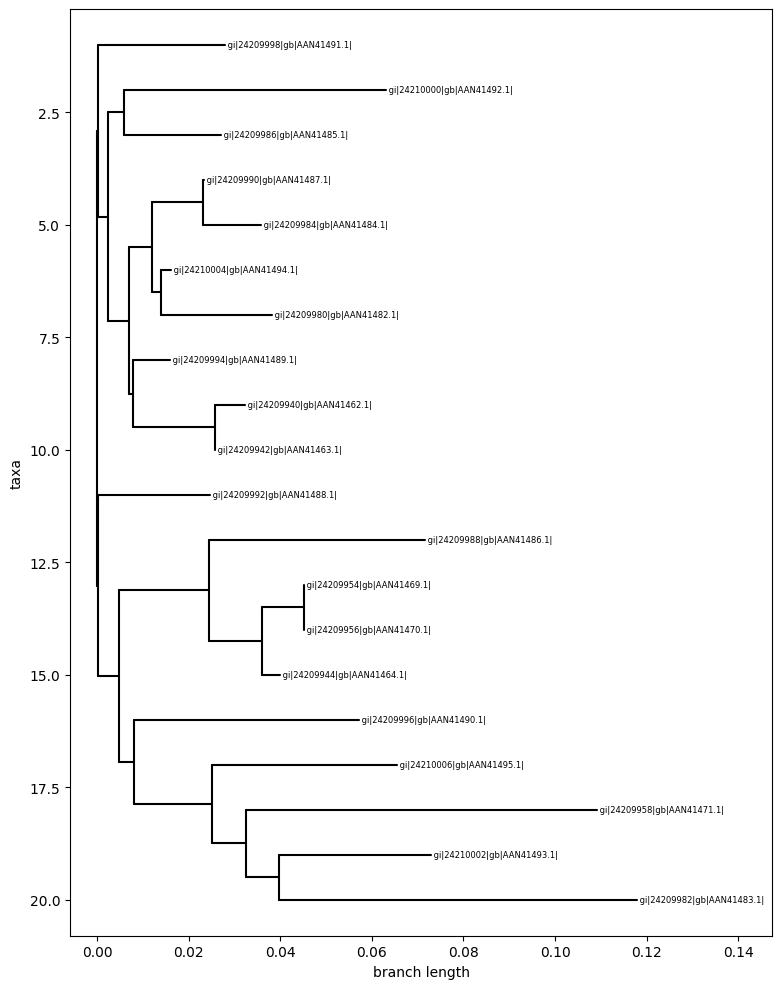

In [5]:
if __name__ == "__main__":
    # Read HIV RT sequences
    sequences = read_fasta("data/lafayette_SARS_RT.fasta")
    
    # Build distance matrix using Smith-Waterman
    dist_matrix, seq_ids = build_distance_matrix(sequences)
    
    # Generate unrooted tree using Neighbor-Joining
    tree = neighbor_joining(dist_matrix, seq_ids)
    
    # Plot tree
    plot_tree(tree)